# AirSense — Forecasting Kualitas Udara 60 Menit ke Depan

Notebook ini digunakan untuk mengembangkan dan mengevaluasi model forecasting konsentrasi polutan 60 menit ke depan.

### Target
Model akan diuji untuk memprediksi:

- PM2.5
- PM10
- CO
- NO₂
- O₃

### Pendekatan
1. Menyiapkan data time-series.
2. Membentuk target t+60.
3. Melakukan feature engineering.
4. Membagi data secara kronologis menjadi train, validation, dan test.
5. Membuat persistence baseline.
6. Membandingkan beberapa candidate model.
7. Mengevaluasi model menggunakan MAE dan RMSE.

> XGBoost digunakan sebagai salah satu candidate model, bukan langsung dianggap sebagai model final.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

# Load Data

In [2]:
DATA_PATH = Path(
    "../../dummy_data/output/dummy_tb_konsentrasi_gas.csv"
)

df = pd.read_csv(DATA_PATH)

df["created_at"] = pd.to_datetime(
    df["created_at"],
    utc=True,
    errors="coerce"
)

df = (
    df
    .dropna(subset=["created_at"])
    .sort_values("created_at")
    .drop_duplicates(subset=["created_at"])
    .reset_index(drop=True)
)

print("Jumlah data :", len(df))
print("Awal        :", df["created_at"].min())
print("Akhir       :", df["created_at"].max())

df.head()

Jumlah data : 10081
Awal        : 2026-08-30 13:49:00+00:00
Akhir       : 2026-09-06 13:49:00+00:00


,created_at,pm25_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,o3_ugm3,temperature,humidity
0,2026-08-30 13:49:00+00:00,11.310,14.870,2682.450,0.420,20.610,38.990,48.400
1,2026-08-30 13:50:00+00:00,16.180,21.710,2673.630,0.000,73.920,36.950,52.980
2,2026-08-30 13:51:00+00:00,15.330,17.590,2818.740,0.000,21.040,37.300,52.370
3,2026-08-30 13:52:00+00:00,13.200,9.970,2548.780,0.430,21.050,38.500,49.880
4,2026-08-30 13:53:00+00:00,16.700,17.530,2537.620,0.000,80.640,38.240,53.810


In [4]:
#Mendefinisikan Parameter
pollutant_cols = [
    "pm25_ugm3",
    "pm10_ugm3",
    "co_ugm3",
    "no2_ugm3",
    "o3_ugm3"
]

environment_cols = [
    "temperature",
    "humidity"
]

forecast_horizon = 60

## Membut Target t+60

In [5]:
for col in pollutant_cols:
    df[f"{col}_target_t60"] = (
        df[col]
        .shift(-forecast_horizon)
    )

In [6]:
#Cek
target_cols = [
    f"{col}_target_t60"
    for col in pollutant_cols
]

df[
    ["created_at"] +
    pollutant_cols +
    target_cols
].head()

,created_at,pm25_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,o3_ugm3,pm25_ugm3_target_t60,pm10_ugm3_target_t60,co_ugm3_target_t60,no2_ugm3_target_t60,o3_ugm3_target_t60
0,2026-08-30 13:49:00+00:00,11.310,14.870,2682.450,0.420,20.610,16.510,21.920,2712.870,0.000,20.200
1,2026-08-30 13:50:00+00:00,16.180,21.710,2673.630,0.000,73.920,16.580,16.740,2809.670,0.000,56.300
2,2026-08-30 13:51:00+00:00,15.330,17.590,2818.740,0.000,21.040,15.390,16.080,2590.170,0.310,20.470
3,2026-08-30 13:52:00+00:00,13.200,9.970,2548.780,0.430,21.050,12.580,13.730,2646.510,0.000,70.180
4,2026-08-30 13:53:00+00:00,16.700,17.530,2537.620,0.000,80.640,16.570,20.750,2638.780,0.000,62.580


## Feature Engineering

In [7]:
#Menggunakan Lag
lags = [1, 10, 30, 60]

for col in pollutant_cols:
    for lag in lags:
        df[f"{col}_lag_{lag}"] = (
            df[col]
            .shift(lag)
        )

In [8]:
rolling_windows = [10, 30, 60]

for col in pollutant_cols:
    for window in rolling_windows:
        df[f"{col}_roll_mean_{window}"] = (
            df[col]
            .rolling(window=window)
            .mean()
        )

        df[f"{col}_roll_std_{window}"] = (
            df[col]
            .rolling(window=window)
            .std()
        )

Ada satu hal penting di sini: rolling dilakukan dari data saat ini dan masa lalu, bukan masa depan. Jadi tidak terjadi leakage ke target t+60.

## Time Features

Karena data disimpan UTC, ubah dahulu ke WIB untuk pola waktu lokal:

In [9]:
df["created_at_local"] = (
    df["created_at"]
    .dt.tz_convert("Asia/Jakarta")
)

df["hour"] = (
    df["created_at_local"]
    .dt.hour
)

df["dayofweek"] = (
    df["created_at_local"]
    .dt.dayofweek
)

In [10]:
#Buat Fitur Siklik
df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)

df["dow_sin"] = np.sin(
    2 * np.pi * df["dayofweek"] / 7
)

df["dow_cos"] = np.cos(
    2 * np.pi * df["dayofweek"] / 7
)

## Susun Feature Columns

In [11]:
feature_cols = []

# Current pollutant values
feature_cols += pollutant_cols

# Environmental features
feature_cols += environment_cols

# Lag features
for col in pollutant_cols:
    for lag in lags:
        feature_cols.append(
            f"{col}_lag_{lag}"
        )

# Rolling features
for col in pollutant_cols:
    for window in rolling_windows:
        feature_cols.append(
            f"{col}_roll_mean_{window}"
        )

        feature_cols.append(
            f"{col}_roll_std_{window}"
        )

# Time features
feature_cols += [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos"
]

print("Jumlah fitur:", len(feature_cols))

Jumlah fitur: 61


## Buang baris yang belum lengkap

Karena ada lag, rolling, dan target t+60, beberapa baris awal/akhir otomatis menjadi NaN.

In [12]:
model_df = (
    df[
        ["created_at"] +
        feature_cols +
        target_cols
    ]
    .dropna()
    .reset_index(drop=True)
)

print("Data awal       :", len(df))
print("Data siap model :", len(model_df))

Data awal       : 10081
Data siap model : 9961


In [13]:
model_df.head()

,created_at,pm25_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,o3_ugm3,temperature,humidity,pm25_ugm3_lag_1,pm25_ugm3_lag_10,pm25_ugm3_lag_30,pm25_ugm3_lag_60,pm10_ugm3_lag_1,pm10_ugm3_lag_10,pm10_ugm3_lag_30,pm10_ugm3_lag_60,co_ugm3_lag_1,co_ugm3_lag_10,co_ugm3_lag_30,co_ugm3_lag_60,no2_ugm3_lag_1,no2_ugm3_lag_10,no2_ugm3_lag_30,no2_ugm3_lag_60,o3_ugm3_lag_1,o3_ugm3_lag_10,o3_ugm3_lag_30,o3_ugm3_lag_60,pm25_ugm3_roll_mean_10,pm25_ugm3_roll_std_10,pm25_ugm3_roll_mean_30,pm25_ugm3_roll_std_30,pm25_ugm3_roll_mean_60,pm25_ugm3_roll_std_60,pm10_ugm3_roll_mean_10,pm10_ugm3_roll_std_10,pm10_ugm3_roll_mean_30,pm10_ugm3_roll_std_30,pm10_ugm3_roll_mean_60,pm10_ugm3_roll_std_60,co_ugm3_roll_mean_10,co_ugm3_roll_std_10,co_ugm3_roll_mean_30,co_ugm3_roll_std_30,co_ugm3_roll_mean_60,co_ugm3_roll_std_60,no2_ugm3_roll_mean_10,no2_ugm3_roll_std_10,no2_ugm3_roll_mean_30,no2_ugm3_roll_std_30,no2_ugm3_roll_mean_60,no2_ugm3_roll_std_60,o3_ugm3_roll_mean_10,o3_ugm3_roll_std_10,o3_ugm3_roll_mean_30,o3_ugm3_roll_std_30,o3_ugm3_roll_mean_60,o3_ugm3_roll_std_60,hour_sin,hour_cos,dow_sin,dow_cos,pm25_ugm3_target_t60,pm10_ugm3_target_t60,co_ugm3_target_t60,no2_ugm3_target_t60,o3_ugm3_target_t60
0,2026-08-30 14:49:00+00:00,16.510,21.920,2712.870,0.000,20.200,37.270,55.390,13.140,14.030,16.130,11.310,12.510,10.120,19.590,14.870,2753.450,2950.430,2638.430,2682.450,0.000,0.000,0.000,0.420,80.820,20.310,20.870,20.610,16.067,1.691,15.681,2.451,15.343,2.489,17.933,2.947,17.468,3.685,17.728,4.010,2723.171,160.637,2694.563,159.731,2682.700,145.928,0.143,0.231,0.145,0.262,0.101,0.230,49.608,25.876,47.105,24.400,46.414,26.343,-0.707,0.707,-0.782,0.623,19.320,21.790,2589.630,0.620,52.690
1,2026-08-30 14:50:00+00:00,16.580,16.740,2809.670,0.000,56.300,37.710,50.700,16.510,16.780,12.900,16.180,21.920,18.080,14.050,21.710,2712.870,2496.180,2614.020,2673.630,0.000,0.000,0.610,0.000,20.200,21.050,73.660,73.920,16.047,1.683,15.803,2.399,15.349,2.492,17.799,2.970,17.558,3.632,17.645,3.978,2754.520,140.779,2701.085,160.322,2684.967,146.838,0.143,0.231,0.124,0.247,0.101,0.230,53.133,23.877,46.526,23.950,46.121,26.128,-0.707,0.707,-0.782,0.623,17.970,23.960,2712.380,0.000,20.830
2,2026-08-30 14:51:00+00:00,15.390,16.080,2590.170,0.310,20.470,37.350,52.240,16.580,17.280,15.360,15.330,16.740,16.490,14.880,17.590,2809.670,2483.400,2660.490,2818.740,0.000,0.000,0.000,0.000,56.300,65.770,66.740,21.040,15.858,1.635,15.804,2.399,15.350,2.492,17.758,2.993,17.598,3.608,17.620,3.983,2765.197,120.523,2698.741,161.446,2681.157,146.273,0.174,0.230,0.135,0.249,0.107,0.231,48.603,25.458,44.984,24.093,46.111,26.138,-0.707,0.707,-0.782,0.623,11.870,19.100,2677.500,0.000,21.080
3,2026-08-30 14:52:00+00:00,12.580,13.730,2646.510,0.000,70.180,38.100,52.110,15.390,15.980,8.820,13.200,16.080,22.210,14.150,9.970,2590.170,2786.560,2665.640,2548.780,0.310,0.470,0.000,0.430,20.470,20.130,73.480,21.050,15.518,1.933,15.930,2.101,15.340,2.502,16.910,2.786,17.584,3.622,17.683,3.889,2751.192,125.787,2698.103,161.619,2682.786,145.315,0.127,0.210,0.135,0.249,0.100,0.227,53.608,24.123,44.874,23.965,46.930,26.109,-0.707,0.707,-0.782,0.623,12.900,13.730,2484.970,1.080,20.750
4,2026-08-30 14:53:00+00:00,16.570,20.750,2638.780,0.000,62.580,38.450,46.820,12.580,15.360,18.680,16.700,13.730,16.860,18.880,17.530,2646.510,2660.320,2578.620,2537.620,0.000,0.510,0.350,0.000,70.180,58.860,21.080,80.640,15.639,1.960,15.859,2.040,15.338,2.501,17.299,3.038,17.646,3.661,17.736,3.909,2749.038,127.686,2700.108,160.455,2684.472,144.185,0.076,0.164,0.123,0.246,0.100,0.227,53.980,24.241,46.257,23.741,46.629,25.816,-0.707,0.707,-0.782,0.623,15.390,16.450,2790.460,0.000,20.310


## Chronological Split

Tidak menggunakan Random Split
Diawal kita pakai 
70% Train
15% Validation
15% Test

In [14]:
n = len(model_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = model_df.iloc[:train_end].copy()

val_df = model_df.iloc[
    train_end:val_end
].copy()

test_df = model_df.iloc[
    val_end:
].copy()

print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

Train      : 6972
Validation : 1494
Test       : 1495


In [15]:
#Cek Rentang Waktu
split_info = pd.DataFrame({
    "Split": [
        "Train",
        "Validation",
        "Test"
    ],
    "Jumlah": [
        len(train_df),
        len(val_df),
        len(test_df)
    ],
    "Awal": [
        train_df["created_at"].min(),
        val_df["created_at"].min(),
        test_df["created_at"].min()
    ],
    "Akhir": [
        train_df["created_at"].max(),
        val_df["created_at"].max(),
        test_df["created_at"].max()
    ]
})

split_info

,Split,Jumlah,Awal,Akhir
0,Train,6972,2026-08-30 14:49:00+00:00,2026-09-04 11:00:00+00:00
1,Validation,1494,2026-09-04 11:01:00+00:00,2026-09-05 11:54:00+00:00
2,Test,1495,2026-09-05 11:55:00+00:00,2026-09-06 12:49:00+00:00


## 8. Persistence Baseline

Persistence baseline digunakan sebagai benchmark sederhana dengan asumsi bahwa konsentrasi polutan 60 menit ke depan sama dengan konsentrasi pada waktu saat ini.

Baseline dievaluasi pada test set yang sama dengan candidate model agar perbandingan performa dilakukan secara adil.

In [16]:
baseline_results = []

for col in pollutant_cols:
    target_col = f"{col}_target_t60"

    y_true = test_df[target_col]
    y_pred = test_df[col]

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    baseline_results.append({
        "Parameter": col,
        "MAE": mae,
        "RMSE": rmse
    })

baseline_test = pd.DataFrame(
    baseline_results
)

baseline_test[
    ["MAE", "RMSE"]
] = baseline_test[
    ["MAE", "RMSE"]
].round(3)

baseline_test

,Parameter,MAE,RMSE
0,pm25_ugm3,5.398,10.306
1,pm10_ugm3,6.866,11.697
2,co_ugm3,265.310,515.309
3,no2_ugm3,0.248,0.439
4,o3_ugm3,8.517,17.623


## 9. Candidate Model 1 — Ridge Regression

Ridge Regression digunakan sebagai candidate model sederhana untuk mengetahui apakah hubungan linear antara fitur historis, parameter lingkungan, dan fitur waktu sudah mampu meningkatkan performa dibandingkan persistence baseline.

Model dilatih menggunakan train set. Validation set digunakan untuk pemilihan hyperparameter, sedangkan test set tetap disimpan untuk evaluasi akhir.

In [17]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [18]:
#Cari alpha Ridge
ridge_alphas = [
    0.01,
    0.1,
    1.0,
    10.0,
    100.0
]

ridge_validation_results = []

X_train = train_df[feature_cols]
X_val = val_df[feature_cols]

for target in pollutant_cols:

    target_col = f"{target}_target_t60"

    y_train = train_df[target_col]
    y_val = val_df[target_col]

    for alpha in ridge_alphas:

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=alpha))
        ])

        model.fit(
            X_train,
            y_train
        )

        pred_val = model.predict(X_val)

        mae = mean_absolute_error(
            y_val,
            pred_val
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_val,
                pred_val
            )
        )

        ridge_validation_results.append({
            "Parameter": target,
            "Alpha": alpha,
            "MAE": mae,
            "RMSE": rmse
        })

ridge_validation_df = pd.DataFrame(
    ridge_validation_results
)

ridge_validation_df[
    ["MAE", "RMSE"]
] = ridge_validation_df[
    ["MAE", "RMSE"]
].round(3)

ridge_validation_df

,Parameter,Alpha,MAE,RMSE
0,pm25_ugm3,0.010,3.742,8.219
1,pm25_ugm3,0.100,3.741,8.218
2,pm25_ugm3,1.000,3.733,8.214
3,pm25_ugm3,10.000,3.707,8.199
4,pm25_ugm3,100.000,3.685,8.183
5,pm10_ugm3,0.010,4.823,9.317
6,pm10_ugm3,0.100,4.823,9.317
7,pm10_ugm3,1.000,4.819,9.314
8,pm10_ugm3,10.000,4.804,9.306
9,pm10_ugm3,100.000,4.794,9.299


In [19]:
#Cari alpha terbaik
best_ridge_params = (
    ridge_validation_df
    .sort_values("MAE")
    .groupby("Parameter", as_index=False)
    .first()
)

best_ridge_params

,Parameter,Alpha,MAE,RMSE
0,co_ugm3,10.000,142.688,184.071
1,no2_ugm3,100.000,2.068,2.629
2,o3_ugm3,100.000,8.024,12.809
3,pm10_ugm3,100.000,4.794,9.299
4,pm25_ugm3,100.000,3.685,8.183


In [20]:
#Train ulang Ridge terbaik
train_val_df = pd.concat(
    [train_df, val_df],
    ignore_index=True
)

X_train_val = train_val_df[feature_cols]
X_test = test_df[feature_cols]

ridge_test_results = []
ridge_models = {}

for _, row in best_ridge_params.iterrows():

    target = row["Parameter"]
    best_alpha = row["Alpha"]

    target_col = f"{target}_target_t60"

    y_train_val = train_val_df[target_col]
    y_test = test_df[target_col]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=best_alpha))
    ])

    model.fit(
        X_train_val,
        y_train_val
    )

    pred_test = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        pred_test
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred_test
        )
    )

    ridge_test_results.append({
        "Parameter": target,
        "Alpha": best_alpha,
        "MAE": mae,
        "RMSE": rmse
    })

    ridge_models[target] = model

ridge_test = pd.DataFrame(
    ridge_test_results
)

ridge_test[
    ["MAE", "RMSE"]
] = ridge_test[
    ["MAE", "RMSE"]
].round(3)

ridge_test

,Parameter,Alpha,MAE,RMSE
0,co_ugm3,10.000,175.067,367.502
1,no2_ugm3,100.000,1.520,1.913
2,o3_ugm3,100.000,8.116,12.814
3,pm10_ugm3,100.000,4.736,8.573
4,pm25_ugm3,100.000,3.680,7.565


In [21]:
#Bandingkan dengan baseline
comparison = baseline_test.merge(
    ridge_test,
    on="Parameter",
    suffixes=(
        "_Persistence",
        "_Ridge"
    )
)

comparison["MAE Improvement (%)"] = (
    (
        comparison["MAE_Persistence"]
        - comparison["MAE_Ridge"]
    )
    / comparison["MAE_Persistence"]
    * 100
)

comparison["RMSE Improvement (%)"] = (
    (
        comparison["RMSE_Persistence"]
        - comparison["RMSE_Ridge"]
    )
    / comparison["RMSE_Persistence"]
    * 100
)

comparison.round(3)

,Parameter,MAE_Persistence,RMSE_Persistence,Alpha,MAE_Ridge,RMSE_Ridge,MAE Improvement (%),RMSE Improvement (%)
0,pm25_ugm3,5.398,10.306,100.000,3.680,7.565,31.827,26.596
1,pm10_ugm3,6.866,11.697,100.000,4.736,8.573,31.022,26.708
2,co_ugm3,265.310,515.309,10.000,175.067,367.502,34.014,28.683
3,no2_ugm3,0.248,0.439,100.000,1.520,1.913,-512.903,-335.763
4,o3_ugm3,8.517,17.623,100.000,8.116,12.814,4.708,27.288


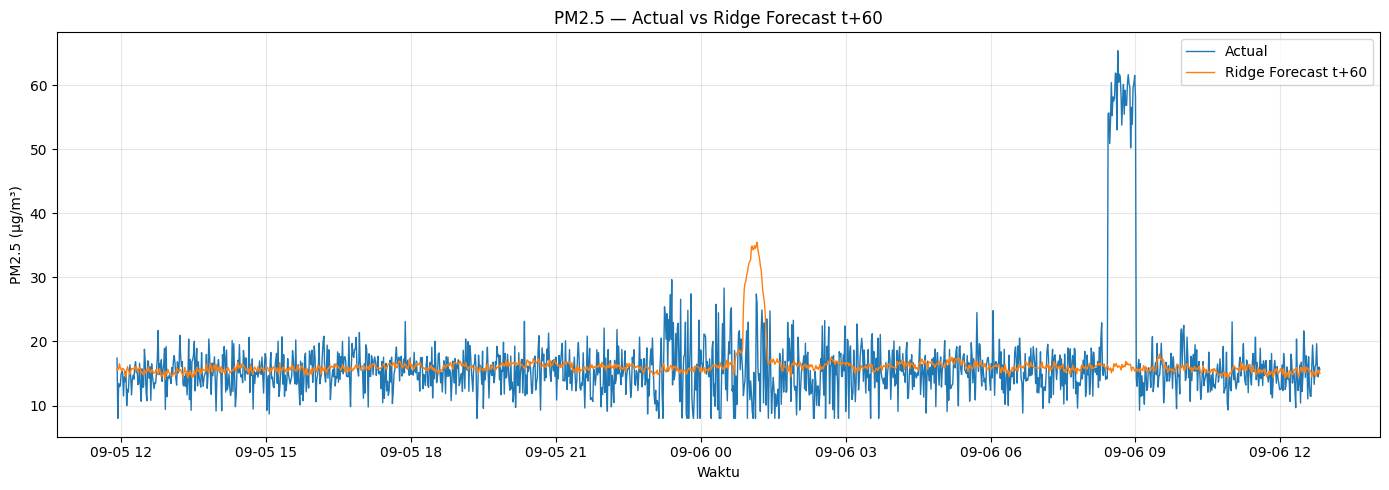

In [22]:
#Visualisasi prediksi
target = "pm25_ugm3"
target_col = f"{target}_target_t60"

y_test = test_df[target_col]

ridge_pred = ridge_models[target].predict(
    X_test
)

plt.figure(figsize=(14, 5))

plt.plot(
    test_df["created_at"],
    y_test,
    label="Actual",
    linewidth=1
)

plt.plot(
    test_df["created_at"],
    ridge_pred,
    label="Ridge Forecast t+60",
    linewidth=1
)

plt.title(
    "PM2.5 — Actual vs Ridge Forecast t+60"
)

plt.xlabel("Waktu")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretasi Ridge Regression

Ridge Regression mampu menurunkan MAE dibandingkan persistence baseline pada PM2.5, PM10, CO, dan O3. Penurunan MAE terbesar diperoleh pada CO, diikuti PM2.5 dan PM10. Hal ini menunjukkan bahwa kombinasi fitur historis, rolling statistics, parameter lingkungan, dan fitur waktu memberikan informasi tambahan untuk forecasting t+60.

Namun, pada NO2, persistence baseline memberikan performa yang jauh lebih baik dibandingkan Ridge Regression. Kondisi ini berkaitan dengan karakteristik data NO2 yang didominasi nilai nol, sehingga mempertahankan nilai saat ini menjadi baseline yang kuat.

Visualisasi PM2.5 juga menunjukkan bahwa Ridge Regression cenderung menghasilkan prediksi yang lebih halus dan belum mampu mengikuti lonjakan konsentrasi secara optimal. Oleh karena itu, diperlukan pengujian model nonlinear untuk mengetahui apakah pola dan perubahan ekstrem dapat dimodelkan dengan lebih baik.

Hasil eksperimen ini masih menggunakan data dummy sehingga digunakan untuk memvalidasi pipeline dan metodologi forecasting, bukan sebagai performa final AirSense.

## 10. Candidate Model 2 — XGBoost

XGBoost digunakan sebagai candidate model nonlinear untuk menangkap hubungan yang lebih kompleks antara konsentrasi polutan saat ini, historical lag, rolling statistics, kondisi lingkungan, dan pola waktu.

Hyperparameter dipilih berdasarkan validation set. Test set tidak digunakan selama proses pemilihan model agar evaluasi akhir tetap independen.

In [23]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.0.5


In [24]:
from xgboost import XGBRegressor

In [25]:
xgb_configs = [
    {
        "name": "XGB_1",
        "n_estimators": 200,
        "max_depth": 3,
        "learning_rate": 0.05
    },
    {
        "name": "XGB_2",
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05
    },
    {
        "name": "XGB_3",
        "n_estimators": 300,
        "max_depth": 6,
        "learning_rate": 0.05
    },
    {
        "name": "XGB_4",
        "n_estimators": 500,
        "max_depth": 4,
        "learning_rate": 0.03
    }
]

In [26]:
#Train Validation
xgb_validation_results = []

X_train = train_df[feature_cols]
X_val = val_df[feature_cols]

for target in pollutant_cols:

    target_col = f"{target}_target_t60"

    y_train = train_df[target_col]
    y_val = val_df[target_col]

    for config in xgb_configs:

        model = XGBRegressor(
            n_estimators=config["n_estimators"],
            max_depth=config["max_depth"],
            learning_rate=config["learning_rate"],
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )

        model.fit(
            X_train,
            y_train
        )

        pred_val = model.predict(X_val)

        mae = mean_absolute_error(
            y_val,
            pred_val
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_val,
                pred_val
            )
        )

        xgb_validation_results.append({
            "Parameter": target,
            "Model": config["name"],
            "n_estimators": config["n_estimators"],
            "max_depth": config["max_depth"],
            "learning_rate": config["learning_rate"],
            "MAE": mae,
            "RMSE": rmse
        })

xgb_validation_df = pd.DataFrame(
    xgb_validation_results
)

xgb_validation_df[
    ["MAE", "RMSE"]
] = xgb_validation_df[
    ["MAE", "RMSE"]
].round(3)

xgb_validation_df

,Parameter,Model,n_estimators,max_depth,learning_rate,MAE,RMSE
0,pm25_ugm3,XGB_1,200,3,0.050,3.878,8.251
1,pm25_ugm3,XGB_2,300,4,0.050,3.720,8.083
2,pm25_ugm3,XGB_3,300,6,0.050,3.750,8.147
3,pm25_ugm3,XGB_4,500,4,0.030,3.792,8.155
4,pm10_ugm3,XGB_1,200,3,0.050,4.936,9.293
5,pm10_ugm3,XGB_2,300,4,0.050,4.841,9.150
6,pm10_ugm3,XGB_3,300,6,0.050,4.914,9.237
7,pm10_ugm3,XGB_4,500,4,0.030,4.923,9.239
8,co_ugm3,XGB_1,200,3,0.050,149.414,216.374
9,co_ugm3,XGB_2,300,4,0.050,152.080,221.472


In [27]:
#Mencari konfigurasi terbaik berdasarkan MAE Validation
best_xgb_params = (
    xgb_validation_df
    .sort_values(["Parameter", "MAE"])
    .groupby(
        "Parameter",
        as_index=False
    )
    .first()
)

best_xgb_params

,Parameter,Model,n_estimators,max_depth,learning_rate,MAE,RMSE
0,co_ugm3,XGB_3,300,6,0.050,142.325,203.041
1,no2_ugm3,XGB_1,200,3,0.050,4.780,11.797
2,o3_ugm3,XGB_1,200,3,0.050,7.701,12.987
3,pm10_ugm3,XGB_2,300,4,0.050,4.841,9.150
4,pm25_ugm3,XGB_2,300,4,0.050,3.720,8.083


### Interpretasi Validation XGBoost

Hasil validation menunjukkan bahwa performa XGBoost berbeda pada setiap parameter. Pada PM2.5 dan PM10, performa XGBoost relatif dekat dengan Ridge Regression, tetapi belum memberikan penurunan MAE. Pada CO, XGBoost memberikan MAE sedikit lebih rendah, sedangkan pada O3 peningkatannya lebih terlihat.

Pada NO2, XGBoost menghasilkan error yang lebih tinggi dibandingkan Ridge Regression. Hal ini memperkuat indikasi bahwa karakteristik NO2 yang didominasi nilai nol dan memiliki spike sesekali menjadi tantangan tersendiri dalam forecasting.

Konfigurasi XGBoost terbaik juga berbeda antarparameter sehingga pemilihan model dan hyperparameter dilakukan secara individual untuk setiap target polutan.

In [28]:
#Evaluasi Final XGBoost
xgb_test_results = []
xgb_models = {}
xgb_test_predictions = {}

X_train_val = train_val_df[feature_cols]
X_test = test_df[feature_cols]

for _, row in best_xgb_params.iterrows():

    target = row["Parameter"]
    target_col = f"{target}_target_t60"

    y_train_val = train_val_df[target_col]
    y_test = test_df[target_col]

    model = XGBRegressor(
        n_estimators=int(row["n_estimators"]),
        max_depth=int(row["max_depth"]),
        learning_rate=float(row["learning_rate"]),
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_val,
        y_train_val
    )

    pred_test = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        pred_test
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred_test
        )
    )

    xgb_test_results.append({
        "Parameter": target,
        "Model": row["Model"],
        "MAE": mae,
        "RMSE": rmse
    })

    xgb_models[target] = model
    xgb_test_predictions[target] = pred_test

xgb_test = pd.DataFrame(xgb_test_results)

xgb_test[
    ["MAE", "RMSE"]
] = xgb_test[
    ["MAE", "RMSE"]
].round(3)

xgb_test

,Parameter,Model,MAE,RMSE
0,co_ugm3,XGB_3,172.610,373.130
1,no2_ugm3,XGB_1,1.720,3.533
2,o3_ugm3,XGB_1,7.846,13.009
3,pm10_ugm3,XGB_2,5.232,9.220
4,pm25_ugm3,XGB_2,4.201,8.285


In [29]:
#Bandingkan tiga pendekatan
final_comparison = (
    baseline_test[
        ["Parameter", "MAE", "RMSE"]
    ]
    .rename(columns={
        "MAE": "MAE_Persistence",
        "RMSE": "RMSE_Persistence"
    })
    .merge(
        ridge_test[
            ["Parameter", "MAE", "RMSE"]
        ].rename(columns={
            "MAE": "MAE_Ridge",
            "RMSE": "RMSE_Ridge"
        }),
        on="Parameter"
    )
    .merge(
        xgb_test[
            ["Parameter", "MAE", "RMSE"]
        ].rename(columns={
            "MAE": "MAE_XGBoost",
            "RMSE": "RMSE_XGBoost"
        }),
        on="Parameter"
    )
)

final_comparison.round(3)

,Parameter,MAE_Persistence,RMSE_Persistence,MAE_Ridge,RMSE_Ridge,MAE_XGBoost,RMSE_XGBoost
0,pm25_ugm3,5.398,10.306,3.680,7.565,4.201,8.285
1,pm10_ugm3,6.866,11.697,4.736,8.573,5.232,9.220
2,co_ugm3,265.310,515.309,175.067,367.502,172.610,373.130
3,no2_ugm3,0.248,0.439,1.520,1.913,1.720,3.533
4,o3_ugm3,8.517,17.623,8.116,12.814,7.846,13.009


In [33]:
# Ringkasan model dengan MAE dan RMSE terendah pada test set

summary_comparison = final_comparison.copy()

summary_comparison["Lowest_MAE"] = (
    summary_comparison[
        [
            "MAE_Persistence",
            "MAE_Ridge",
            "MAE_XGBoost"
        ]
    ]
    .idxmin(axis=1)
    .map({
        "MAE_Persistence": "Persistence",
        "MAE_Ridge": "Ridge",
        "MAE_XGBoost": "XGBoost"
    })
)

summary_comparison["Lowest_RMSE"] = (
    summary_comparison[
        [
            "RMSE_Persistence",
            "RMSE_Ridge",
            "RMSE_XGBoost"
        ]
    ]
    .idxmin(axis=1)
    .map({
        "RMSE_Persistence": "Persistence",
        "RMSE_Ridge": "Ridge",
        "RMSE_XGBoost": "XGBoost"
    })
)

summary_comparison.round(3)

,Parameter,MAE_Persistence,RMSE_Persistence,MAE_Ridge,RMSE_Ridge,MAE_XGBoost,RMSE_XGBoost,Lowest_Test_MAE,Lowest_MAE,Lowest_RMSE
0,pm25_ugm3,5.398,10.306,3.680,7.565,4.201,8.285,Ridge,Ridge,Ridge
1,pm10_ugm3,6.866,11.697,4.736,8.573,5.232,9.220,Ridge,Ridge,Ridge
2,co_ugm3,265.310,515.309,175.067,367.502,172.610,373.130,XGBoost,XGBoost,Ridge
3,no2_ugm3,0.248,0.439,1.520,1.913,1.720,3.533,Persistence,Persistence,Persistence
4,o3_ugm3,8.517,17.623,8.116,12.814,7.846,13.009,XGBoost,XGBoost,Ridge


### Interpretasi Evaluasi Final Model

Evaluasi pada test set menunjukkan bahwa tidak terdapat satu pendekatan yang memberikan performa terbaik untuk seluruh parameter polutan.

Untuk PM2.5 dan PM10, Ridge Regression menghasilkan MAE dan RMSE yang lebih rendah dibandingkan Persistence dan XGBoost. Hal ini menunjukkan bahwa pada data eksperimen saat ini, hubungan antara fitur historis dan target t+60 pada kedua parameter tersebut dapat dimodelkan dengan cukup baik menggunakan pendekatan linear yang teratur.

Pada CO, XGBoost menghasilkan MAE sedikit lebih rendah dibandingkan Ridge Regression, yaitu 172.610 dibandingkan 175.067. Namun, Ridge memiliki RMSE yang sedikit lebih rendah. Oleh karena itu, keunggulan XGBoost pada CO belum bersifat mutlak dan perlu dievaluasi kembali ketika data riil yang lebih panjang tersedia.

Pada O3, XGBoost menghasilkan MAE terendah, sedangkan Ridge menghasilkan RMSE yang sedikit lebih rendah. Perbedaan metrik ini menunjukkan bahwa pemilihan model tidak sebaiknya hanya didasarkan pada satu ukuran error.

Pada NO2, Persistence Baseline memberikan performa terbaik dengan MAE 0.248 dan RMSE 0.439. Kondisi ini berkaitan dengan karakteristik data NO2 yang didominasi nilai nol, sehingga model yang mempertahankan nilai saat ini menjadi benchmark yang sangat kuat.

Secara keseluruhan, hasil eksperimen menunjukkan bahwa model forecasting dapat berbeda untuk setiap parameter. Hasil ini masih berbasis data dummy sehingga digunakan untuk memvalidasi metodologi dan pipeline forecasting. Pemilihan model final AirSense perlu dievaluasi kembali menggunakan data riil IoT dengan periode observasi yang lebih panjang.

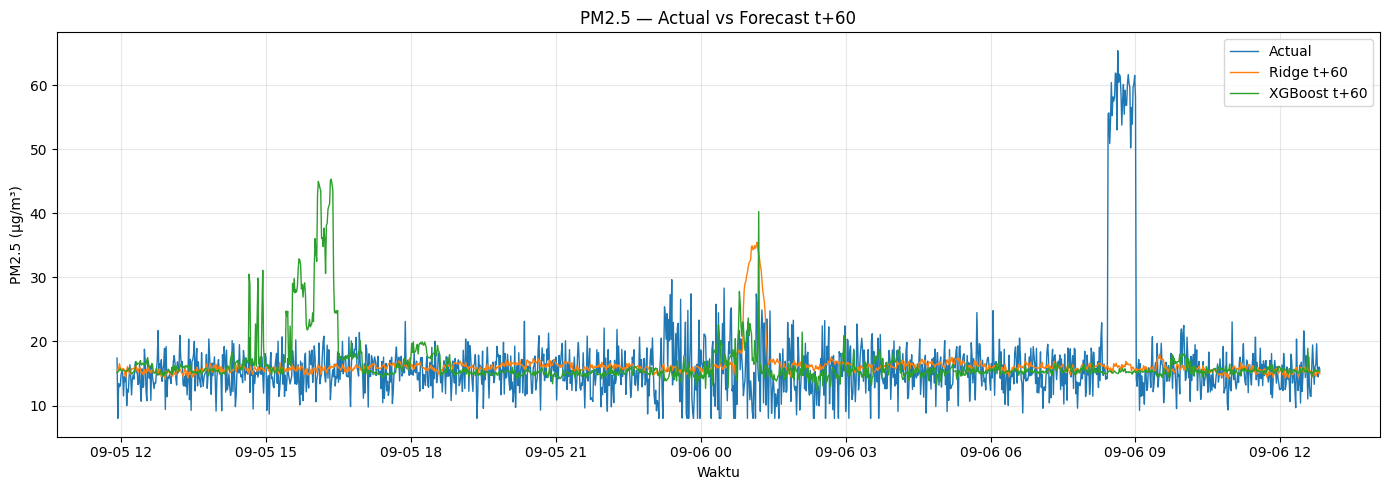

In [34]:
#Lihat CGBoost pada spike PM2.5
target = "pm25_ugm3"
target_col = f"{target}_target_t60"

y_test = test_df[target_col]

ridge_pred = ridge_models[target].predict(
    X_test
)

xgb_pred = xgb_test_predictions[target]

plt.figure(figsize=(14, 5))

plt.plot(
    test_df["created_at"],
    y_test,
    label="Actual",
    linewidth=1
)

plt.plot(
    test_df["created_at"],
    ridge_pred,
    label="Ridge t+60",
    linewidth=1
)

plt.plot(
    test_df["created_at"],
    xgb_pred,
    label="XGBoost t+60",
    linewidth=1
)

plt.title(
    "PM2.5 — Actual vs Forecast t+60"
)

plt.xlabel("Waktu")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretasi Visual Forecast PM2.5

Visualisasi menunjukkan bahwa Ridge Regression menghasilkan prediksi yang relatif stabil dan cenderung berada di sekitar pola umum konsentrasi PM2.5. XGBoost mampu menghasilkan variasi prediksi yang lebih besar, tetapi beberapa lonjakan prediksi tidak sesuai dengan nilai aktual.

Kedua model belum mampu mengantisipasi lonjakan aktual PM2.5 yang terjadi pada periode pengujian. Hal ini menunjukkan bahwa performa rata-rata berdasarkan MAE dan RMSE belum sepenuhnya menggambarkan kemampuan model dalam memprediksi kejadian ekstrem.

Temuan ini menjadi alasan penting untuk memisahkan fungsi forecasting dan anomaly detection pada AirSense. Forecasting digunakan untuk memperkirakan konsentrasi 60 menit ke depan, sedangkan anomaly detection digunakan untuk mengidentifikasi perubahan atau kondisi yang tidak biasa.

## 11. Feature Importance XGBoost

Feature importance digunakan untuk melihat fitur yang paling banyak dimanfaatkan oleh model XGBoost dalam membentuk prediksi.

Analisis ini bersifat interpretatif dan tidak menunjukkan hubungan sebab-akibat. Nilai feature importance hanya menunjukkan kontribusi relatif fitur dalam proses prediksi model.

In [35]:
#Feature Importance PM2.5
target = "pm25_ugm3"

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": xgb_models[target].feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

importance_df.head(15)

,Feature,Importance
0,pm25_ugm3_roll_std_60,0.134
1,dow_sin,0.095
2,co_ugm3_roll_std_60,0.060
3,pm10_ugm3_roll_mean_60,0.054
4,co_ugm3_roll_mean_30,0.042
5,pm25_ugm3_roll_std_30,0.040
6,pm10_ugm3_roll_std_60,0.038
7,o3_ugm3_roll_std_60,0.037
8,hour_cos,0.035
9,co_ugm3_roll_mean_60,0.034


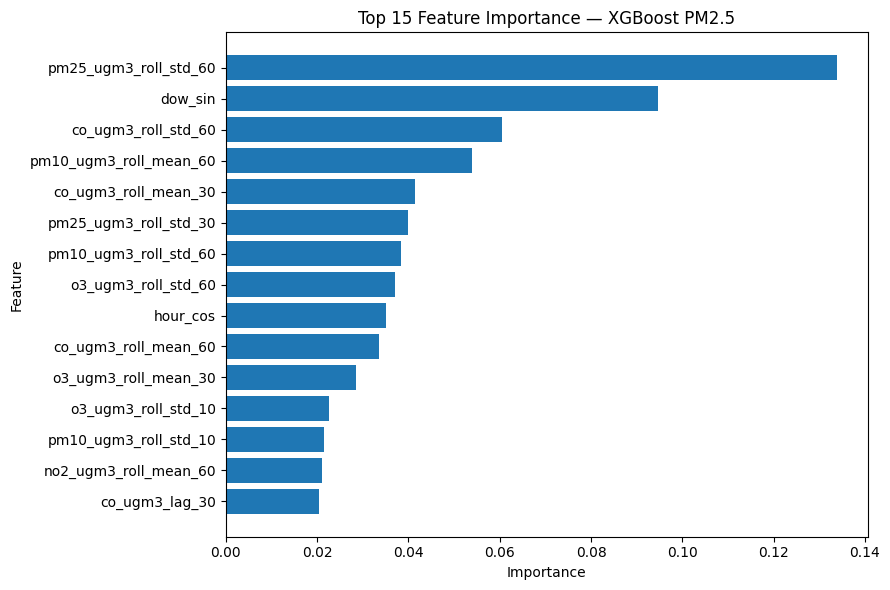

In [36]:
#Visualisasi 15 Teratas
top_features = importance_df.head(15)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title(
    "Top 15 Feature Importance — XGBoost PM2.5"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Interpretasi Feature Importance

Feature importance XGBoost menunjukkan bahwa fitur `pm25_ugm3_roll_std_60` memiliki importance tertinggi pada model forecasting PM2.5. Hal ini menunjukkan bahwa variasi konsentrasi PM2.5 dalam window 60 menit merupakan salah satu informasi yang banyak dimanfaatkan model dalam membentuk prediksi.

Selain fitur PM2.5, beberapa fitur dari polutan lain seperti CO, PM10, O3, dan NO2 juga muncul pada feature importance teratas. Fitur waktu seperti `dow_sin` dan `hour_cos` juga digunakan oleh model, yang menunjukkan bahwa informasi temporal ikut berkontribusi dalam proses prediksi.

Feature importance tidak menunjukkan hubungan sebab-akibat, melainkan hanya kontribusi relatif fitur terhadap prediksi model. Selain itu, karena eksperimen masih menggunakan data dummy dengan periode sekitar tujuh hari, pola feature importance belum dapat dianggap mewakili kondisi lingkungan sebenarnya dan perlu dievaluasi kembali menggunakan data riil.

### Menyimpan Hasil Forecast untuk Integrasi

Prediksi konsentrasi t+60 pada test set disimpan agar dapat digunakan pada tahap pengembangan alert logic.

Output ini masih merupakan hasil eksperimen menggunakan data dummy dan tidak merepresentasikan model produksi final AirSense.

In [41]:
# Membentuk output forecast t+60

forecast_output = pd.DataFrame({
    "created_at": test_df["created_at"].values
})

for target in pollutant_cols:

    # Nilai aktual t+60
    forecast_output[
        f"{target}_actual_t60"
    ] = test_df[
        f"{target}_target_t60"
    ].values

    # Prediksi model
    predictions = np.array(
        xgb_test_predictions[target]
    )

    # Konsentrasi secara fisik tidak boleh negatif.
    # Nilai negatif dibatasi menjadi 0 pada output forecast.
    predictions = np.clip(
        predictions,
        a_min=0,
        a_max=None
    )

    forecast_output[
        f"{target}_forecast_t60"
    ] = predictions

In [42]:
#Timestamp kapan prediksi berlaku
forecast_output["created_at"] = pd.to_datetime(
    forecast_output["created_at"],
    utc=True
)

forecast_output["forecast_at"] = (
    forecast_output["created_at"]
    + pd.Timedelta(minutes=60)
)

forecast_output[
    [
        "created_at",
        "forecast_at"
    ]
].head()

,created_at,forecast_at
0,2026-09-05 11:55:00+00:00,2026-09-05 12:55:00+00:00
1,2026-09-05 11:56:00+00:00,2026-09-05 12:56:00+00:00
2,2026-09-05 11:57:00+00:00,2026-09-05 12:57:00+00:00
3,2026-09-05 11:58:00+00:00,2026-09-05 12:58:00+00:00
4,2026-09-05 11:59:00+00:00,2026-09-05 12:59:00+00:00


In [43]:
# Memastikan tidak terdapat prediksi konsentrasi negatif

forecast_cols = [
    f"{col}_forecast_t60"
    for col in pollutant_cols
]

negative_check = pd.DataFrame({
    "Parameter": pollutant_cols,
    "Negative_Count": [
        (
            forecast_output[
                f"{col}_forecast_t60"
            ] < 0
        ).sum()
        for col in pollutant_cols
    ]
})

negative_check

,Parameter,Negative_Count
0,pm25_ugm3,0
1,pm10_ugm3,0
2,co_ugm3,0
3,no2_ugm3,0
4,o3_ugm3,0


In [46]:
#Simpan Forecast
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

forecast_output.to_csv(
    OUTPUT_DIR / "forecast_t60_results.csv",
    index=False
)

print(
    "Hasil forecast t+60 berhasil disimpan."
)

print(
    "Jumlah forecast:",
    len(forecast_output)
)

print(
    "Forecast dibuat dari:",
    forecast_output["created_at"].min(),
    "sampai",
    forecast_output["created_at"].max()
)

print(
    "Forecast berlaku untuk:",
    forecast_output["forecast_at"].min(),
    "sampai",
    forecast_output["forecast_at"].max()
)

Hasil forecast t+60 berhasil disimpan.
Jumlah forecast: 1495
Forecast dibuat dari: 2026-09-05 11:55:00+00:00 sampai 2026-09-06 12:49:00+00:00
Forecast berlaku untuk: 2026-09-05 12:55:00+00:00 sampai 2026-09-06 13:49:00+00:00


## 12. Kesimpulan Forecasting

Eksperimen forecasting dilakukan untuk memprediksi konsentrasi PM2.5, PM10, CO, NO2, dan O3 pada horizon 60 menit ke depan menggunakan pendekatan Persistence Baseline, Ridge Regression, dan XGBoost.

Data dibagi secara kronologis menjadi train, validation, dan test untuk menjaga urutan temporal dan mencegah penggunaan informasi masa depan pada proses pelatihan. Candidate features meliputi nilai polutan saat ini, historical lag, rolling statistics, parameter lingkungan, dan fitur waktu.

Hasil evaluasi menunjukkan bahwa tidak terdapat satu model yang secara konsisten unggul pada seluruh parameter. Ridge Regression menghasilkan MAE dan RMSE terendah untuk PM2.5 dan PM10. Pada CO dan O3, hasil Ridge dan XGBoost relatif kompetitif dengan perbedaan antara MAE dan RMSE. Sementara itu, Persistence Baseline memberikan performa terbaik pada NO2 karena karakteristik data yang didominasi nilai nol.

Visualisasi PM2.5 menunjukkan bahwa model masih mengalami kesulitan dalam mengantisipasi lonjakan konsentrasi yang ekstrem. Oleh karena itu, forecasting dan anomaly detection diperlakukan sebagai dua fungsi yang berbeda dalam AirSense.

Hasil eksperimen ini digunakan untuk memvalidasi pipeline dan metodologi forecasting. Model final belum ditetapkan karena eksperimen masih menggunakan data dummy dengan periode observasi yang terbatas. Pemilihan dan pelatihan model akan dievaluasi kembali menggunakan data riil dari perangkat IoT.

In [37]:
#SImpan Hasil Evaluasi Eksperimen
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

summary_comparison.to_csv(
    OUTPUT_DIR / "forecast_model_comparison.csv",
    index=False
)

importance_df.to_csv(
    OUTPUT_DIR / "pm25_xgb_feature_importance.csv",
    index=False
)

print(
    "Hasil evaluasi forecasting berhasil disimpan."
)

Hasil evaluasi forecasting berhasil disimpan.
